# Compartment models

**Reza Sameni**  
Emory University

SEIRP dynamics, healthcare saturation, and controlled SI models.

## Topics

- Interpret SEIRP transition rates.
- Verify conservation numerically.
- Compare adequate and saturated healthcare resources.

**Run:** install the package with `python -m pip install -e ".[notebooks,dev]"`, then run all cells in order. All numerical functions are imported from `src/epidemic_modeling`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, HTML
import epidemic_modeling as em
from epidemic_modeling.plotting import configure_plots, repository_root, plot_compartments, plot_growth
root = repository_root()
configure_plots()
print(f"epidemic_modeling {em.__version__} · local data")

epidemic_modeling 2.0.0 · local data


## SEIRP equations

Let $q=\alpha_e se+\alpha_i si$. Then

$$\dot s=-q+\gamma r,\quad \dot e=q-(\kappa+\rho)e,\quad
\dot i=\kappa e-(\beta+\mu)i,\quad
\dot r=\beta i+\rho e-\gamma r,\quad \dot p=\mu i.$$

The five derivatives sum to zero. Forward Euler preserves this linear invariant, but a coarse step can still produce negative states. Choose a fine grid and inspect the trajectories.

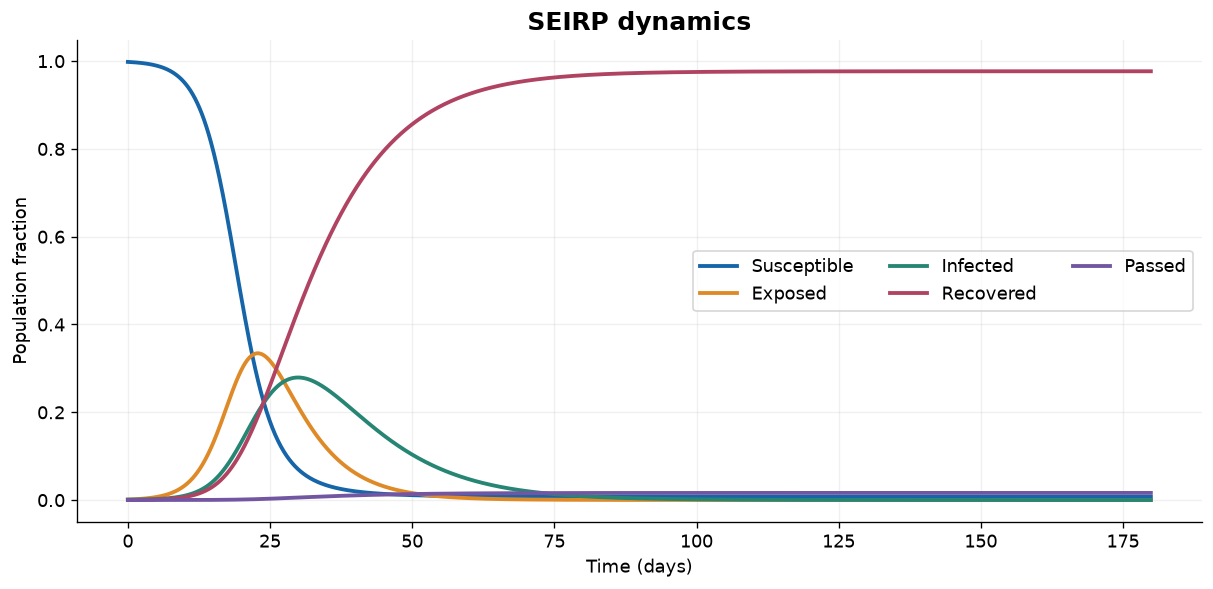

Maximum mass error: 1.33e-15


In [2]:
dt, duration = 0.1, 180.0
initial = (0.998, 0.001, 0.001, 0.0, 0.0)
states = em.seirp(0.4, 0.3, 0.12, 0.04, 0.09, 0.002, 0.0, *initial, duration, dt)
time = np.arange(len(states[0]))*dt
plot_compartments(time, states); plt.show()
print(f'Maximum mass error: {np.max(np.abs(np.sum(states, axis=0)-1)):.2e}')
assert np.allclose(np.sum(states, axis=0), 1, atol=1e-12)

## A smooth capacity threshold

Healthcare saturation uses $h(i)=\frac12[1+\tanh((i-i_0)/\sigma)]$.
Recovery interpolates from $\beta_0$ to $\beta_s$; mortality interpolates from $\mu_0$ to $\mu_s$. This represents a model assumption, not a fitted clinical capacity measure.

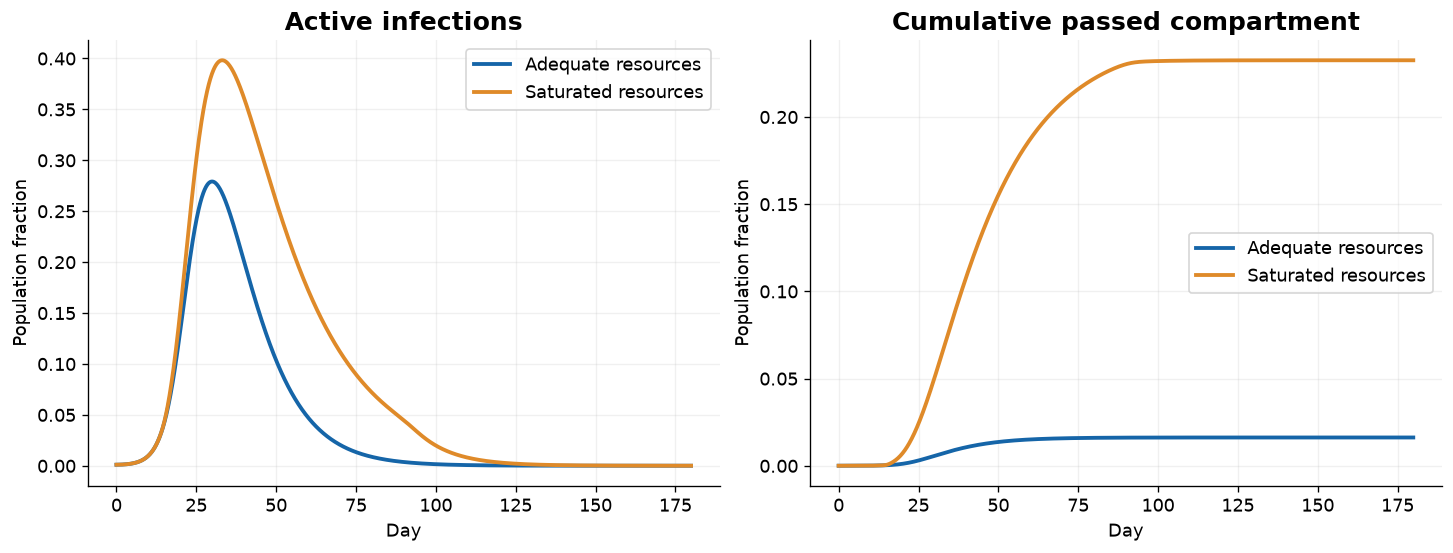

In [3]:
saturated = em.seirp_saturated_resource(0.4, 0.3, 0.12, 0.04, 0.0, *initial, duration, dt, 0.09, 0.03, 0.002, 0.015, 0.01, 0.04)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for trajectory, label in [(states, 'Adequate resources'), (saturated, 'Saturated resources')]:
    axes[0].plot(time, trajectory[2], label=label)
    axes[1].plot(time, trajectory[4], label=label)
axes[0].set(title='Active infections', xlabel='Day', ylabel='Population fraction')
axes[1].set(title='Cumulative passed compartment', xlabel='Day', ylabel='Population fraction')
for ax in axes: ax.legend()
plt.show()

## Time-dependent intervention

A step reduction in the contact rate lets us inspect controlled SI dynamics. The initial condition is at time zero, and `count` is the number of returned samples.

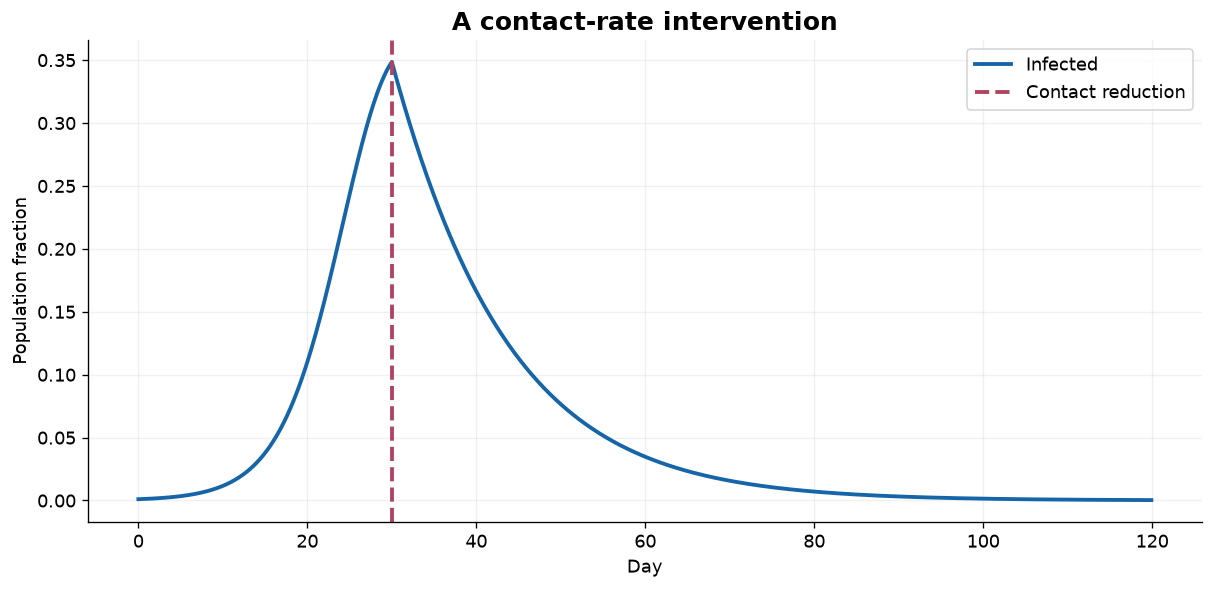

In [4]:
contact = np.r_[np.full(300, 0.35), np.full(900, 0.08)]
s, i = em.si_controlled(contact, 0.1, 0.999, 0.001, len(contact), dt)
fig, ax = plt.subplots()
ax.plot(np.arange(len(i))*dt, i, label='Infected')
ax.axvline(30, color='#b14362', linestyle='--', label='Contact reduction')
ax.set(title='A contact-rate intervention', xlabel='Day', ylabel='Population fraction'); ax.legend(); plt.show()

## Further experiments

- Halve `dt` while preserving duration. Compare peaks and final mortality.
- Introduce a nonzero loss-of-immunity rate `gamma`.
- Explain why clipping each SEIRP compartment independently would break conservation.

**Paired MATLAB example:** `demo_compartment_models`.

## References and next steps

1. Reza Sameni (2020). *Mathematical Modeling of Epidemic Diseases; A Case Study of the COVID-19 Coronavirus*. [arXiv:2003.11371](https://arxiv.org/abs/2003.11371).
2. Reza Sameni (2022). *Model-Based Prediction and Optimal Control of Pandemics by Non-Pharmaceutical Interventions*. IEEE JSTSP, **16**(2), 307–317. [DOI:10.1109/JSTSP.2021.3129118](https://doi.org/10.1109/JSTSP.2021.3129118).

Equations and existing research images originate from the cited work and the [original repository](https://github.com/alphanumericslab/EpidemicModeling). Consult `docs/api.md` for array shapes and `docs/migration.md` for deliberate fixes.